# Whale Signals Real-Time Analysis

This notebook provides focused whale analysis with real-time signal detection for TUTUSDC trading. It extracts the core visualization and adds boolean signal functions for automated trading decisions.

## Key Features:
- **Real-time Whale Detection**: Boolean signals for large orders, price crosses, and activity thresholds
- **Focused Visualization**: 5-chart analysis showing critical whale patterns
- **Alert System**: Automated monitoring of whale activity and buying pressure
- **Trading Signals**: Clear boolean outputs for algorithmic trading integration

## Signal Definitions:
1. **Large Orders Threshold**: Whale activity exceeding 15% threshold
2. **Price-Concentration Cross**: Price movement crossing whale concentration indicator
3. **Whale Activity Surge**: Activity surpassing 3% price rise threshold
4. **Low Buying Pressure**: Abnormally low taker buy ratios

Fetching data for TUTUSDC...
Current Whale Signals:
  large_orders_threshold: 🟢
  price_concentration_cross: 🔴
  whale_activity_surge: 🔴
  buying_pressure_low: 🔴


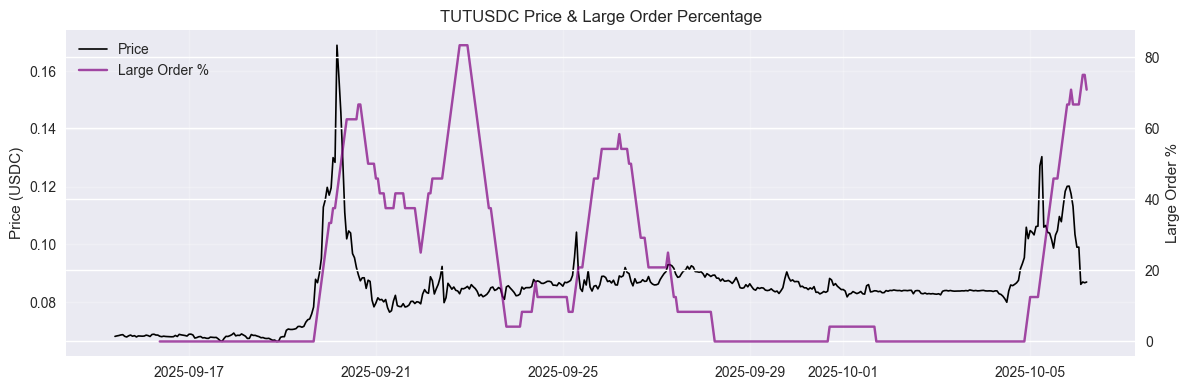

Done. Single consolidated analysis complete.


In [ ]:
# Whale Signals Real-Time - Single Cell Consolidated Version

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from typing import Optional, Dict
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")


# ----------------------------- Data Fetch -----------------------------
def fetch_binance_klines(
    symbol: str, interval: str = "1h", limit: int = 500, end_time: Optional[int] = None
) -> pd.DataFrame:
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    if end_time:
        params["endTime"] = end_time
    r = requests.get(url, params=params, timeout=10)
    r.raise_for_status()
    data = r.json()
    if not data:
        raise RuntimeError("Empty response from Binance")
    df = pd.DataFrame(
        data,
        columns=[
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "close_time",
            "quote_asset_volume",
            "number_of_trades",
            "taker_base",
            "taker_quote",
            "ignore",
        ],
    )
    num_cols = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "number_of_trades",
        "taker_base",
        "taker_quote",
    ]
    df[num_cols] = df[num_cols].astype(float)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    return (
        df[
            [
                "timestamp",
                "open",
                "high",
                "low",
                "close",
                "volume",
                "quote_asset_volume",
                "taker_base",
                "taker_quote",
                "number_of_trades",
            ]
        ]
        .sort_values("timestamp")
        .reset_index(drop=True)
    )


# ---------------------- Indicator & Signal Pipeline -------------------
def calculate_money_flow_indicators(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["inflow"] = df["taker_quote"]
    df["outflow"] = df["quote_asset_volume"] - df["taker_quote"]
    df["net_money_flow"] = df["inflow"] - df["outflow"]
    df["money_flow_ratio"] = df["inflow"] / (df["outflow"] + 1e-10)
    df["taker_buy_ratio"] = df["taker_base"] / (df["volume"] + 1e-10)
    df["money_flow_strength"] = (df["inflow"] - df["outflow"]) / (
        df["inflow"] + df["outflow"] + 1e-10
    )
    return df


def detect_large_orders(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    volume_thr = df["volume"].quantile(0.80)
    quote_thr = df["quote_asset_volume"].quantile(0.85)
    trades_thr = df["number_of_trades"].quantile(0.75)
    df["is_large_order"] = (
        (df["volume"] >= volume_thr) | (df["quote_asset_volume"] >= quote_thr)
    ) & (df["number_of_trades"] >= trades_thr)
    df["large_order_pct"] = df["is_large_order"].rolling(24).mean() * 100
    df["avg_trade_size"] = df["volume"] / (df["number_of_trades"] + 1e-10)
    return df


def calculate_concentration_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    def gini(x: np.ndarray) -> float:
        x = x[x > 0]
        if len(x) == 0:
            return 0.0
        x = np.sort(x)
        n = len(x)
        cum = np.cumsum(x)
        return (2 * np.sum((np.arange(1, n + 1) * x))) / (n * cum[-1]) - (n + 1) / n

    df["volume_concentration"] = (
        df["volume"].rolling(24).apply(lambda s: gini(s.values) * 100, raw=False)
    )
    df["large_order_clustering"] = df["large_order_pct"].rolling(12).std() * 2
    df["concentration_score"] = 0.6 * df["volume_concentration"].fillna(0) + 0.4 * df[
        "large_order_clustering"
    ].fillna(0)
    return df


def detect_price_and_whale_signals(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["price_change_4h"] = df["close"].pct_change(4) * 100
    df["whale_activity_clustering"] = df["large_order_pct"].rolling(3).sum()
    high_activity_thr = df["whale_activity_clustering"].quantile(0.80)
    df["high_whale_activity"] = df["whale_activity_clustering"] > high_activity_thr
    df["taker_buy_surge"] = df["taker_buy_ratio"] > df["taker_buy_ratio"].rolling(
        24
    ).quantile(0.85)
    df["whale_price_predictor"] = (
        df["high_whale_activity"]
        & df["taker_buy_surge"]
        & (df["concentration_score"] > 25)
    )
    df["whale_accumulation"] = (df["large_order_pct"] > 15) & (
        df["money_flow_strength"] > 0.1
    )
    df["whale_distribution"] = (df["large_order_pct"] > 15) & (
        df["money_flow_strength"] < -0.1
    )
    return df


# ---------------------- Real-Time Boolean Signals ----------------------
def get_whale_signals_current(df: pd.DataFrame) -> Dict[str, bool]:
    if df.empty:
        return {
            k: False
            for k in [
                "large_orders_threshold",
                "price_concentration_cross",
                "whale_activity_surge",
                "buying_pressure_low",
            ]
        }
    latest = df.iloc[-1]
    large_orders_threshold = latest["large_order_pct"] > 15.0
    if len(df) >= 3:
        price_mom = (df["close"].iloc[-1] / df["close"].iloc[-3] - 1) * 100
        conc_mom = (
            df["concentration_score"].iloc[-1] - df["concentration_score"].iloc[-3]
        )
        price_concentration_cross = (
            price_mom > 2.0 and conc_mom > 5.0 and latest["concentration_score"] > 30
        )
    else:
        price_concentration_cross = False
    whale_activity_surge = (
        latest["whale_activity_clustering"]
        > df["whale_activity_clustering"].quantile(0.85)
        and latest["concentration_score"] > 25
        and latest["money_flow_strength"] > 0.05
    )
    taker_buy_threshold = df["taker_buy_ratio"].quantile(0.25)
    buying_pressure_low = (
        latest["taker_buy_ratio"] < taker_buy_threshold
        and latest["taker_buy_ratio"] < 0.45
        and latest["money_flow_strength"] < -0.1
    )
    return {
        "large_orders_threshold": bool(large_orders_threshold),
        "price_concentration_cross": bool(price_concentration_cross),
        "whale_activity_surge": bool(whale_activity_surge),
        "buying_pressure_low": bool(buying_pressure_low),
    }


# ------------------------- Single Example Run --------------------------
symbol = "TUTUSDC"
print(f"Fetching data for {symbol}...")
df = fetch_binance_klines(symbol, interval="1h", limit=500)
df = calculate_money_flow_indicators(df)
df = detect_large_orders(df)
df = calculate_concentration_metrics(df)
df = detect_price_and_whale_signals(df)
signals = get_whale_signals_current(df)
print("Current Whale Signals:")
for k, v in signals.items():
    print(f"  {k}: {'🟢' if v else '🔴'}")

# Minimal quick look plot (price & large order %)
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.plot(df["timestamp"], df["close"], color="black", linewidth=1.2, label="Price")
ax2.plot(
    df["timestamp"],
    df["large_order_pct"],
    color="purple",
    alpha=0.7,
    label="Large Order %",
)
ax1.set_ylabel("Price (USDC)")
ax2.set_ylabel("Large Order %")
ax1.set_title("TUTUSDC Price & Large Order Percentage")
ax1.grid(alpha=0.25)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")
plt.tight_layout()
plt.show()

print("Done. Single consolidated analysis complete.")